# Notebook 01 — Environment Setup
Setup environment dan struktur folder untuk project Lip Reading SIBI

**Dataset: Label Gabungan (Angka + Alphabet + Kata)**
- Angka   : `1, 2, 3, 8, 9, 10`
- Alphabet: `a, b, c, d, e, f`
- Kata    : `buku, dia, saya, keliling, kelompok, sekarang`
- **Total : 18 label × 200 video = 3.600 video**
  - Train : 140 video/label × 18 = 2.520 video
  - Val   :  40 video/label × 18 =   720 video
  - Test  :  20 video/label × 18 =   360 video

In [2]:
# ── Cek versi Python dan waktu sekarang
import sys
import os
from datetime import datetime

print(f"Python   : {sys.version}")
print(f"Waktu    : {datetime.now().strftime('%Y-%m-%d %H:%M:%S')}")
print(f"Direktori: {os.getcwd()}")

Python   : 3.12.3 (main, Mar  3 2026, 12:15:18) [GCC 13.3.0]
Waktu    : 2026-04-02 11:36:18
Direktori: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/notebooks


In [3]:
# ── Cek PyTorch dan GPU
import torch

print(f"PyTorch : {torch.__version__}")
print(f"CUDA    : {torch.cuda.is_available()}")

if torch.cuda.is_available():
    props = torch.cuda.get_device_properties(0)
    total = props.total_memory / 1024**3
    used  = torch.cuda.memory_allocated(0) / 1024**3

    print(f"GPU     : {props.name}")
    print(f"VRAM    : {used:.2f} / {total:.2f} GB digunakan")

    # Tes sederhana apakah GPU bisa dipakai
    t = torch.randn(100, 100).cuda()
    _ = t @ t.T
    del t
    torch.cuda.empty_cache()
    print("CUDA test: OK ✓")
else:
    print("WARNING: CUDA tidak tersedia, training akan sangat lambat!")

PyTorch : 2.11.0+cu128
CUDA    : True
GPU     : NVIDIA GeForce RTX 5050 Laptop GPU
VRAM    : 0.00 / 7.54 GB digunakan
CUDA test: OK ✓


In [4]:
# ── Cek semua library yang dibutuhkan
packages = {
    'numpy'     : 'NumPy',
    'cv2'       : 'OpenCV',
    'mediapipe' : 'MediaPipe',
    'matplotlib': 'Matplotlib',
    'seaborn'   : 'Seaborn',
    'sklearn'   : 'Scikit-learn',
    'pandas'    : 'Pandas',
    'tqdm'      : 'TQDM',
}

print("Checking packages...\n")
missing = []

for mod, name in packages.items():
    try:
        m = __import__(mod)
        print(f"  ✓ {name:15s}: {getattr(m, '__version__', '?')}")
    except ImportError:
        print(f"  ✗ {name:15s}: NOT INSTALLED")
        missing.append(mod)

print()
if missing:
    print("Package yang belum terinstall:")
    for m in missing:
        print(f"  pip install {m} --break-system-packages")
else:
    print("Semua package sudah terinstall ✓")

Checking packages...

  ✓ NumPy          : 2.4.3
  ✓ OpenCV         : 4.13.0
  ✓ MediaPipe      : 0.10.33
  ✓ Matplotlib     : 3.10.8
  ✓ Seaborn        : 0.13.2
  ✓ Scikit-learn   : 1.8.0
  ✓ Pandas         : 3.0.2
  ✓ TQDM           : 4.67.3

Semua package sudah terinstall ✓


In [5]:
# ── Import semua library sekaligus
import numpy as np
import pandas as pd
import cv2
import mediapipe as mp
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
from tqdm import tqdm
from pathlib import Path
import json

plt.style.use('seaborn-v0_8-darkgrid')
print("Semua library berhasil diimport ✓")

Semua library berhasil diimport ✓


In [6]:
# ── Setup path dan variabel global
BASE_DIR     = Path('/home/wipra-ranum/Documents/Skripsi/LipReading')
PROJECT_ROOT = BASE_DIR / 'Lip_Reading_Gabungan'
DATA_ROOT    = BASE_DIR / 'Dependent'

# Label gabungan: angka + alphabet + kata
CLASSES_ANGKA    = ['1', '2', '3', '8', '9', '10']
CLASSES_ALPHABET = ['a', 'b', 'c', 'd', 'e', 'f']
CLASSES_KATA     = ['buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']
CLASSES          = CLASSES_ANGKA + CLASSES_ALPHABET + CLASSES_KATA   # total 18 label

SPLITS = ['train', 'val', 'test']

# Jumlah video per label
N_TRAIN = 140
N_VAL   = 40
N_TEST  = 20

# Folder output preprocessing
RAW_LIPS_DIR      = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'raw_lips'
OPTICAL_FLOWS_DIR = PROJECT_ROOT / 'preprocessed' / 'dependent' / 'optical_flows'

# Folder lainnya
MODELS_DIR  = PROJECT_ROOT / 'models'
LOGS_DIR    = PROJECT_ROOT / 'logs'
RESULTS_DIR = PROJECT_ROOT / 'results'
UTILS_DIR   = PROJECT_ROOT / 'utils'

print(f"BASE_DIR     : {BASE_DIR}")
print(f"PROJECT_ROOT : {PROJECT_ROOT}")
print(f"DATA_ROOT    : {DATA_ROOT}")
print(f"\nTotal label  : {len(CLASSES)}")
print(f"  Angka    ({len(CLASSES_ANGKA)}) : {CLASSES_ANGKA}")
print(f"  Alphabet ({len(CLASSES_ALPHABET)}) : {CLASSES_ALPHABET}")
print(f"  Kata     ({len(CLASSES_KATA)}) : {CLASSES_KATA}")
print(f"\nTotal video  : {len(CLASSES) * (N_TRAIN + N_VAL + N_TEST)} video")
print(f"  Train : {N_TRAIN} × {len(CLASSES)} = {N_TRAIN * len(CLASSES)} video")
print(f"  Val   : {N_VAL}  × {len(CLASSES)} = {N_VAL   * len(CLASSES)} video")
print(f"  Test  : {N_TEST}  × {len(CLASSES)} = {N_TEST  * len(CLASSES)} video")

BASE_DIR     : /home/wipra-ranum/Documents/Skripsi/LipReading
PROJECT_ROOT : /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan
DATA_ROOT    : /home/wipra-ranum/Documents/Skripsi/LipReading/Dependent

Total label  : 18
  Angka    (6) : ['1', '2', '3', '8', '9', '10']
  Alphabet (6) : ['a', 'b', 'c', 'd', 'e', 'f']
  Kata     (6) : ['buku', 'dia', 'saya', 'keliling', 'kelompok', 'sekarang']

Total video  : 3600 video
  Train : 140 × 18 = 2520 video
  Val   : 40  × 18 = 720 video
  Test  : 20  × 18 = 360 video


In [7]:
# ── Buat struktur folder project
print("Membuat struktur folder...\n")

folders = [
    PROJECT_ROOT / 'notebooks',
    UTILS_DIR,
    MODELS_DIR / 'checkpoints',
    MODELS_DIR / 'best',
    LOGS_DIR,
    RESULTS_DIR / 'dependent',
    RESULTS_DIR / 'visualizations',
]

# Folder per split per label untuk raw_lips dan optical_flows
for split in SPLITS:
    for cls in CLASSES:
        folders.append(RAW_LIPS_DIR / split / cls)
        folders.append(OPTICAL_FLOWS_DIR / split / cls)

created = 0
for folder in folders:
    if not folder.exists():
        folder.mkdir(parents=True, exist_ok=True)
        print(f"  [dibuat] {folder.relative_to(PROJECT_ROOT)}")
        created += 1
    else:
        print(f"  [ada   ] {folder.relative_to(PROJECT_ROOT)}")

print(f"\nSelesai — {created} folder baru dibuat ✓")

# Buat __init__.py di utils
init_file = UTILS_DIR / '__init__.py'
if not init_file.exists():
    init_file.write_text('# Utils package untuk project SIBI Lip Reading\n')
    print("utils/__init__.py dibuat ✓")

Membuat struktur folder...

  [ada   ] notebooks
  [ada   ] utils
  [ada   ] models/checkpoints
  [ada   ] models/best
  [ada   ] logs
  [ada   ] results/dependent
  [ada   ] results/visualizations
  [ada   ] preprocessed/dependent/raw_lips/train/1
  [ada   ] preprocessed/dependent/optical_flows/train/1
  [ada   ] preprocessed/dependent/raw_lips/train/2
  [ada   ] preprocessed/dependent/optical_flows/train/2
  [ada   ] preprocessed/dependent/raw_lips/train/3
  [ada   ] preprocessed/dependent/optical_flows/train/3
  [ada   ] preprocessed/dependent/raw_lips/train/8
  [ada   ] preprocessed/dependent/optical_flows/train/8
  [ada   ] preprocessed/dependent/raw_lips/train/9
  [ada   ] preprocessed/dependent/optical_flows/train/9
  [ada   ] preprocessed/dependent/raw_lips/train/10
  [ada   ] preprocessed/dependent/optical_flows/train/10
  [ada   ] preprocessed/dependent/raw_lips/train/a
  [ada   ] preprocessed/dependent/optical_flows/train/a
  [ada   ] preprocessed/dependent/raw_lips/train/b


In [8]:
# ── Verifikasi data source (Dependent)
print(f"Mengecek data di: {DATA_ROOT}\n")

grand_total   = 0
split_summary = {}
data_verified = False

if not DATA_ROOT.exists():
    print(f"ERROR: Folder 'Dependent' tidak ditemukan di {BASE_DIR}")
    print(f"Pastikan struktur: {DATA_ROOT}/train/<label>/*.mp4")
else:
    expected = {'train': N_TRAIN, 'val': N_VAL, 'test': N_TEST}

    for split in SPLITS:
        split_total = 0
        print(f"── {split.upper()} ──")

        for cls in CLASSES:
            p = DATA_ROOT / split / cls
            if p.exists():
                videos = (list(p.glob('*.mp4')) + list(p.glob('*.avi')) +
                          list(p.glob('*.mov')) + list(p.glob('*.mkv')))
                n = len(videos)
            else:
                n = 0

            ok     = n == expected[split]
            status = '✓' if ok else ('⚠' if n > 0 else '✗')
            print(f"  {status} {cls:>10s} : {n:3d} video", end='')
            if not ok:
                print(f"  (ekspektasi: {expected[split]})", end='')
            print()

            split_total  += n
            grand_total  += n

        split_summary[split] = split_total
        print()

    print(f"{'─'*40}")
    for split, n in split_summary.items():
        print(f"  {split:5s} total : {n:5d} video")
    print(f"  GRAND TOTAL : {grand_total:5d} video")
    print(f"{'─'*40}")

    if grand_total > 0:
        data_verified = True
        print("\nVerifikasi data: OK ✓")
    else:
        print("\nVerifikasi data: GAGAL ✗ — tidak ada video ditemukan")

Mengecek data di: /home/wipra-ranum/Documents/Skripsi/LipReading/Dependent

── TRAIN ──
  ✓          1 : 140 video
  ✓          2 : 140 video
  ✓          3 : 140 video
  ✓          8 : 140 video
  ✓          9 : 140 video
  ✓         10 : 140 video
  ✓          a : 140 video
  ✓          b : 140 video
  ✓          c : 140 video
  ✓          d : 140 video
  ✓          e : 140 video
  ✓          f : 140 video
  ✓       buku : 140 video
  ✓        dia : 140 video
  ✓       saya : 140 video
  ✓   keliling : 140 video
  ✓   kelompok : 140 video
  ✓   sekarang : 140 video

── VAL ──
  ✓          1 :  40 video
  ✓          2 :  40 video
  ✓          3 :  40 video
  ✓          8 :  40 video
  ✓          9 :  40 video
  ✓         10 :  40 video
  ✓          a :  40 video
  ✓          b :  40 video
  ✓          c :  40 video
  ✓          d :  40 video
  ✓          e :  40 video
  ✓          f :  40 video
  ✓       buku :  40 video
  ✓        dia :  40 video
  ✓       saya :  40 video
  ✓   keli

In [9]:
# ── Simpan konfigurasi ke config.json
config = {
    'paths': {
        'base_dir'          : str(BASE_DIR),
        'project_root'      : str(PROJECT_ROOT),
        'data_root'         : str(DATA_ROOT),
        'raw_lips_dir'      : str(RAW_LIPS_DIR),
        'optical_flows_dir' : str(OPTICAL_FLOWS_DIR),
        'models_dir'        : str(MODELS_DIR),
        'logs_dir'          : str(LOGS_DIR),
        'results_dir'       : str(RESULTS_DIR),
    },
    'data': {
        'classes'         : CLASSES,
        'classes_angka'   : CLASSES_ANGKA,
        'classes_alphabet': CLASSES_ALPHABET,
        'classes_kata'    : CLASSES_KATA,
        'num_classes'     : len(CLASSES),
        'splits'          : SPLITS,
        'videos_per_label': {'train': N_TRAIN, 'val': N_VAL, 'test': N_TEST},
        'total_videos'    : len(CLASSES) * (N_TRAIN + N_VAL + N_TEST),
    },
    'preprocessing': {
        'num_frames'            : 30,
        'lip_size'              : [64, 64],
        'frame_selection_method': 'difference',
        'face_detector'         : 'MediaPipe',
    },
    'optical_flow': {
        'method'       : 'Lucas-Kanade',
        'normalization': 'global',
    },
    'training': {
        'batch_size'     : 4,
        'num_epochs'     : 30,
        'learning_rate'  : 0.001,
        'num_workers'    : 2,
        'sequence_length': 30,
        'input_size'     : 64,
        'input_channels' : 3,
        'num_classes'    : len(CLASSES),
    },
}

config_path = PROJECT_ROOT / 'config.json'
config_path.write_text(json.dumps(config, indent=4))
print(f"Config disimpan ke: {config_path} ✓")

Config disimpan ke: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/config.json ✓


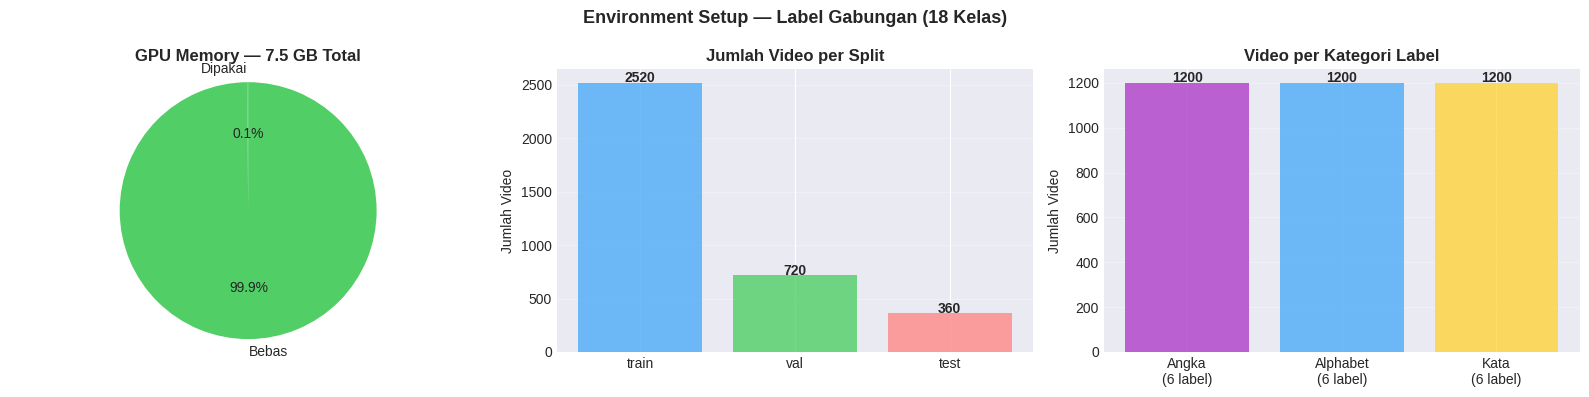

Plot disimpan ke: /home/wipra-ranum/Documents/Skripsi/LipReading/Lip_Reading_Gabungan/results/environment_summary.png ✓


In [10]:
# ── Visualisasi ringkasan setup
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle('Environment Setup — Label Gabungan (18 Kelas)', fontsize=13, fontweight='bold')

# Plot 1: GPU memory
ax = axes[0]
if torch.cuda.is_available():
    total = torch.cuda.get_device_properties(0).total_memory / 1024**3
    used  = torch.cuda.memory_allocated(0) / 1024**3
    ax.pie([used, total - used], labels=['Dipakai', 'Bebas'],
           colors=['#ff6b6b', '#51cf66'], autopct='%1.1f%%', startangle=90)
    ax.set_title(f'GPU Memory — {total:.1f} GB Total', fontweight='bold')
else:
    ax.text(0.5, 0.5, 'Tidak ada GPU', ha='center', va='center', color='red')
    ax.set_title('GPU Status')
ax.axis('equal')

# Plot 2: Jumlah video per split
ax = axes[1]
counts = [split_summary.get(s, 0) for s in SPLITS]
bars   = ax.bar(SPLITS, counts, color=['#4dabf7', '#51cf66', '#ff8787'], alpha=0.8)
for bar, val in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Jumlah Video per Split', fontweight='bold')
ax.set_ylabel('Jumlah Video')
ax.grid(axis='y', alpha=0.3)

# Plot 3: Distribusi label per kategori
ax = axes[2]
kategori = ['Angka\n(6 label)', 'Alphabet\n(6 label)', 'Kata\n(6 label)']
jumlah   = [
    len(CLASSES_ANGKA)    * (N_TRAIN + N_VAL + N_TEST),
    len(CLASSES_ALPHABET) * (N_TRAIN + N_VAL + N_TEST),
    len(CLASSES_KATA)     * (N_TRAIN + N_VAL + N_TEST),
]
bars = ax.bar(kategori, jumlah, color=['#ae3ec9', '#4dabf7', '#ffd43b'], alpha=0.8)
for bar, val in zip(bars, jumlah):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
            str(val), ha='center', fontweight='bold')
ax.set_title('Video per Kategori Label', fontweight='bold')
ax.set_ylabel('Jumlah Video')
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
out = RESULTS_DIR / 'environment_summary.png'
out.parent.mkdir(parents=True, exist_ok=True)
plt.savefig(out, dpi=150, bbox_inches='tight')
plt.show()
print(f"Plot disimpan ke: {out} ✓")

In [11]:
# ── Final checklist
checks = {
    'PyTorch OK'               : True,
    'CUDA tersedia'            : torch.cuda.is_available(),
    'Semua package OK'         : len(missing) == 0,
    'DATA_ROOT ada'            : DATA_ROOT.exists(),
    'Data terverifikasi'       : data_verified,
    'PROJECT_ROOT ada'         : PROJECT_ROOT.exists(),
    'Folder raw_lips OK'       : (RAW_LIPS_DIR / 'train' / CLASSES[0]).exists(),
    'Folder optical_flows OK'  : (OPTICAL_FLOWS_DIR / 'train' / CLASSES[0]).exists(),
    'config.json tersimpan'    : config_path.exists(),
}

for item, status in checks.items():
    print(f"  {'✓' if status else '✗'} {item}")

print()
if all(checks.values()):
    print("Semua OK — lanjut ke Notebook 02: Data Audit ✓")
else:
    failed = [k for k, v in checks.items() if not v]
    print(f"Ada yang perlu diperbaiki: {failed}")

  ✓ PyTorch OK
  ✓ CUDA tersedia
  ✓ Semua package OK
  ✓ DATA_ROOT ada
  ✓ Data terverifikasi
  ✓ PROJECT_ROOT ada
  ✓ Folder raw_lips OK
  ✓ Folder optical_flows OK
  ✓ config.json tersimpan

Semua OK — lanjut ke Notebook 02: Data Audit ✓
